## Lithofacies Prediction frow Well Log Data Using Machine Learning

- Importing all the required packages

In [1]:
import numpy as np
import pandas as pd
import random
from random import randint
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns

random.seed()

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.metrics import categorical_crossentropy
from sklearn.model_selection import train_test_split

In [2]:
train_data = pd.read_csv('train.csv', sep=';')
test_data = pd.read_csv('test.csv', sep=';')

In [3]:
train_data.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,34.636410,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000,1.0
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,34.636410,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000,1.0
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,34.779556,NaN,NaN,-0.574245,NaN,NaN,NaN,NaN,65000,1.0
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,39.965164,NaN,NaN,-0.586315,NaN,NaN,NaN,NaN,65000,1.0
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,57.483765,NaN,NaN,-0.597914,NaN,NaN,NaN,NaN,65000,1.0


In [4]:
train_data.shape

(1170511, 29)

In [5]:
train_data.columns

Index(['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION',
       'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC',
       'ROPA', 'RXO', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [6]:
train_data['FORCE_2020_LITHOFACIES_LITHOLOGY'].unique()

array([65000, 30000, 65030, 70000, 99000, 80000, 86000, 74000, 70032,
       90000, 88000, 93000], dtype=int64)

In [7]:
# map of lithologies to encoding
lithology_keys = {30000: 'Sandstone',
                 65030: 'Sandstone/Shale',
                 65000: 'Shale',
                 80000: 'Marl',
                 74000: 'Dolomite',
                 70000: 'Limestone',
                 70032: 'Chalk',
                 88000: 'Halite',
                 86000: 'Anhydrite',
                 99000: 'Tuff',
                 90000: 'Coal',
                 93000: 'Basement'}

Text(0, 0.5, 'Lithology presence (\\%)')

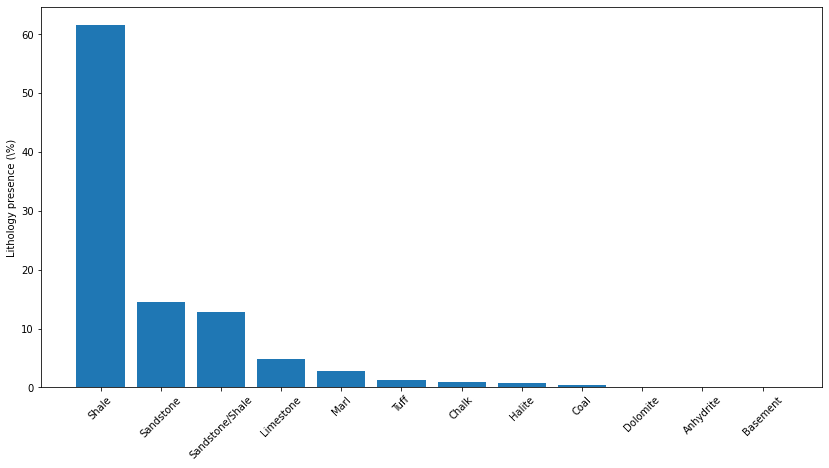

In [8]:
counts = train_data['FORCE_2020_LITHOFACIES_LITHOLOGY'].value_counts()
names = []
percentage = []
N = train_data['FORCE_2020_LITHOFACIES_LITHOLOGY'].shape[0]
for item in counts.iteritems():
    names.append(lithology_keys[item[0]])
    percentage.append(float(item[1])/N*100)
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.bar(x=np.arange(len(names)), height=percentage)
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=45)
ax.set_ylabel('Lithology presence (\%)')

In [9]:
labels = dict(train_data.FORCE_2020_LITHOFACIES_LITHOLOGY.value_counts())

In [11]:
train_data.isna().sum().sort_values(ascending = False)

SGR                                  1101158
DTS                                   995898
RMIC                                  994351
ROPA                                  978186
DCAL                                  871678
MUDWEIGHT                             854360
RXO                                   843084
ROP                                   635440
RSHA                                  539861
PEF                                   498819
BS                                    487854
NPHI                                  405102
SP                                    306264
DRHO                                  182654
RHOB                                  161269
FORMATION                             136994
CALI                                   87877
DTC                                    80863
RMED                                   38993
RDEP                                   11015
Z_LOC                                  10775
Y_LOC                                  10775
X_LOC     

From the above table we will remove the columns which has high missing values

## Preparing the data for training

- converting lithology labels to numbers before training
- removing columns with high missing values
- removing highly coorelated features
- filling the missing values with 0
- shuffling the dataset to prevent overfitting
- normalizing the dataset
- reshaping the data as an input for for 1-D CNN

In [14]:
X = train_data
Y = train_data['FORCE_2020_LITHOFACIES_LITHOLOGY']
lithology_numbers = {30000: 0,
                     65030: 1,
                     65000: 2,
                     80000: 3,
                     74000: 4,
                     70000: 5,
                     70032: 6,
                     88000: 7,
                     86000: 8,
                     99000: 9,
                     90000: 10,
                     93000: 11}

Y = Y.map(lithology_numbers)
Y = pd.DataFrame(Y)

In [15]:
X = X.drop('FORCE_2020_LITHOFACIES_LITHOLOGY', axis = 1)
X = X.drop('FORCE_2020_LITHOFACIES_CONFIDENCE', axis = 1)
X = X.drop('WELL', axis = 1)
X = X.drop('GROUP',axis = 1)
X = X.drop('FORMATION',axis = 1)
X = X.drop('RMIC', axis =1)
X = X.drop('DTS', axis =1)
X = X.drop('ROPA', axis =1)
X = X.drop('RXO', axis =1)
X = X.drop('MUDWEIGHT', axis =1)
X = X.drop('DCAL', axis =1)
X = X.drop('BS', axis =1)
X= X.drop('Z_LOC', axis =1)

In [16]:
X.fillna(0, inplace=True)

In [17]:
Y,X = shuffle(Y,X)
X.head()

,DEPTH_MD,X_LOC,Y_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,ROP,DRHO
166777,2359.756000,442817.71875,6461115.0,10.676240,0.000000,2.547847,1.699351,2.493277,8.623760,0.0,0.198233,0.000000,77.267937,155.039597,7.828067,-0.019328
1051886,1967.614000,531920.68750,6766804.0,8.551857,3.184542,3.180671,2.183268,2.392063,91.942619,0.0,0.337503,4.189888,92.960136,28.039801,0.000000,0.021229
324729,3189.238805,454469.53125,6603730.0,12.777678,0.000000,1.910932,1.708296,2.505761,42.754349,0.0,0.301412,0.000000,92.783455,0.000000,0.000000,0.000000
761237,2055.520000,460101.56250,6783936.5,8.570300,2.628872,1.506474,0.905406,1.947090,58.894165,0.0,0.380451,0.000000,126.581825,74.751648,0.000000,-0.015414
853000,1236.913436,482076.09375,6847169.5,17.973501,0.000000,1.961879,2.621020,0.000000,51.851646,0.0,0.000000,0.000000,118.954842,25.051069,0.000000,0.000000


In [18]:
X.shape

(1170511, 16)

In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [20]:
X = sc.fit_transform(X)
X.shape, Y.shape

((1170511, 16), (1170511, 1))

In [21]:
X[0]

array([ 0.17616554, -0.66403792, -0.24382434, -0.30137501, -0.07779723,
       -0.04227916, -0.07839394,  0.63644421, -1.81966865, -0.21418701,
       -0.09920938, -0.40895133, -0.69281905,  1.56172023, -0.05269825,
       -0.00431191])

In [22]:
# reshaping the data
X = np.reshape(X,( X.shape[0], X.shape[1], 1))

In [23]:
X.shape, Y.shape

((1170511, 16, 1), (1170511, 1))

##  Modelling Data

In [24]:
#Importing convolutional layers

from tensorflow.keras.layers import Convolution1D
from tensorflow.keras.layers import MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, SpatialDropout1D
 
from tensorflow.keras.metrics import categorical_crossentropy

In [41]:
model = Sequential()

#Input shape must be explicitly defined, DO NOT USE (None,shape)!!!
#1.Multiple convolution and max pooling
model.add(Convolution1D(filters=64, kernel_size=3, activation="relu", input_shape=(16,1)))
model.add(BatchNormalization())
model.add(Convolution1D(filters=64, kernel_size=3, activation='relu'))
model.add(BatchNormalization( ))

model.add(MaxPooling1D(pool_size=5, strides=1))
model.add(BatchNormalization( ))


model.add(Convolution1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization( ))
model.add(Convolution1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization( ))

model.add(MaxPooling1D(pool_size=4, strides=1))
model.add(BatchNormalization( ))

model.add(Flatten())

model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(12, activation='softmax'))


# #Configure the learning process
model.compile(Adam(learning_rate = 0.01), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# #Train!
model.fit(X, Y, batch_size=1024, epochs=10, shuffle = True, validation_split=0.05)

Epoch 1/10
1086/1086 [==============================] - 877s 798ms/step - loss: 0.6800 - accuracy: 0.7823 - val_loss: 0.5266 - val_accuracy: 0.8266
Epoch 2/10
1086/1086 [==============================] - 916s 843ms/step - loss: 0.5177 - accuracy: 0.8350 - val_loss: 0.4427 - val_accuracy: 0.8546
Epoch 3/10
1086/1086 [==============================] - 934s 860ms/step - loss: 0.4803 - accuracy: 0.8460 - val_loss: 0.4350 - val_accuracy: 0.8570
Epoch 4/10
1086/1086 [==============================] - 911s 839ms/step - loss: 0.4588 - accuracy: 0.8520 - val_loss: 0.4353 - val_accuracy: 0.8570
Epoch 5/10
1086/1086 [==============================] - 914s 841ms/step - loss: 0.4447 - accuracy: 0.8561 - val_loss: 0.3933 - val_accuracy: 0.8729
Epoch 6/10
1086/1086 [==============================] - 896s 825ms/step - loss: 0.4369 - accuracy: 0.8588 - val_loss: 0.4272 - val_accuracy: 0.8622
Epoch 7/10
1086/1086 [==============================] - 927s 853ms/step - loss: 0.4278 - accuracy: 0.8611 - val_

In [42]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 14, 64)            256       
                                                                 
 batch_normalization_6 (Batc  (None, 14, 64)           256       
 hNormalization)                                                 
                                                                 
 conv1d_5 (Conv1D)           (None, 12, 64)            12352     
                                                                 
 batch_normalization_7 (Batc  (None, 12, 64)           256       
 hNormalization)                                                 
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 8, 64)            0         
 1D)                                                             
                                                      

In [62]:
model.evaluate(x=X, y=Y)

36579/36579 [==============================] - 610s 17ms/step - loss: 0.5011 - accuracy: 0.8380


[0.5010570287704468, 0.8380151987075806]